<a href="https://colab.research.google.com/github/OSMANHASSAN-dev/codealpha_tasks/blob/main/Iris_Classification2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load your uploaded dataset
df = pd.read_csv('Iris.csv')

# Drop the 'Id' column as it is not a feature for training
df = df.drop('Id', axis=1)

print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


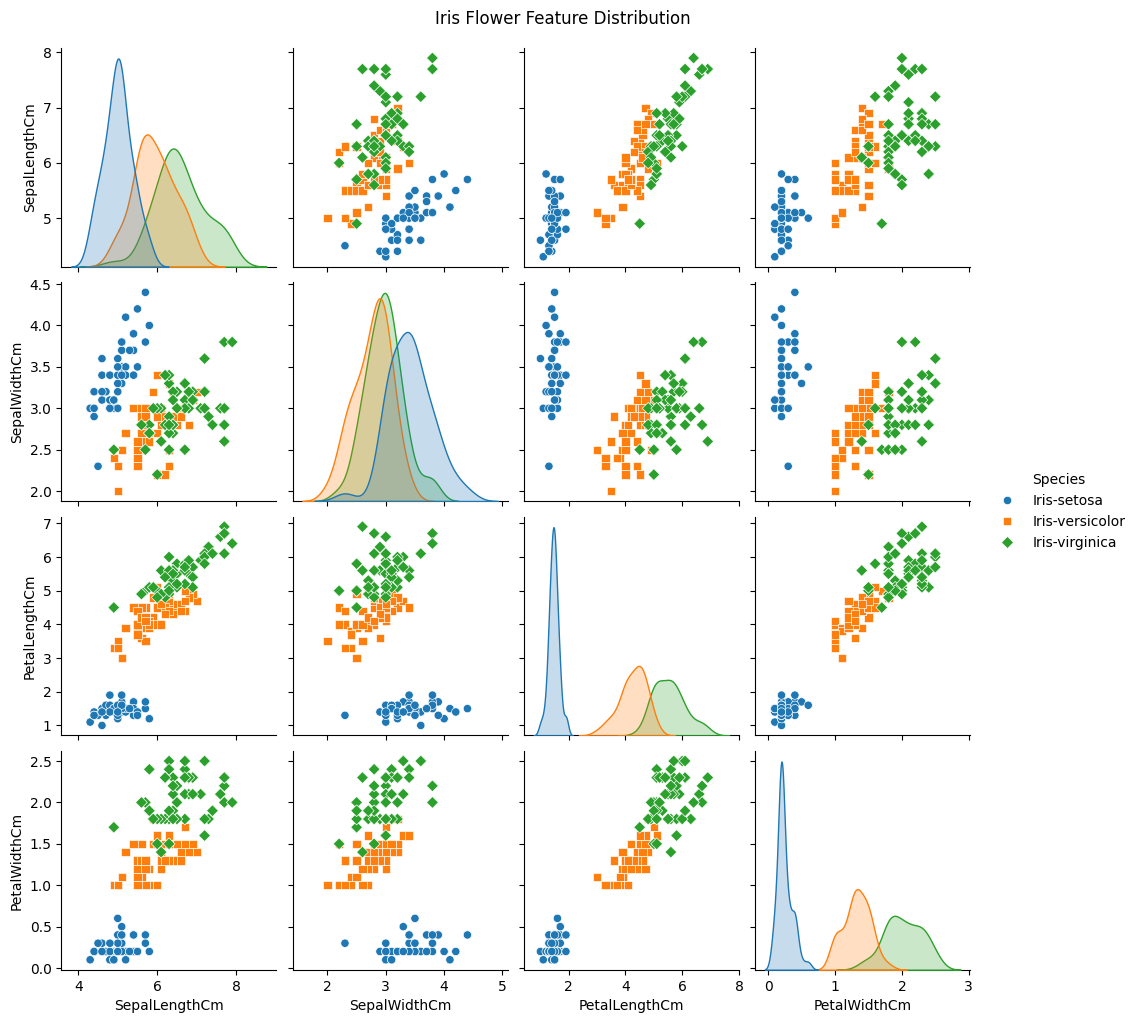

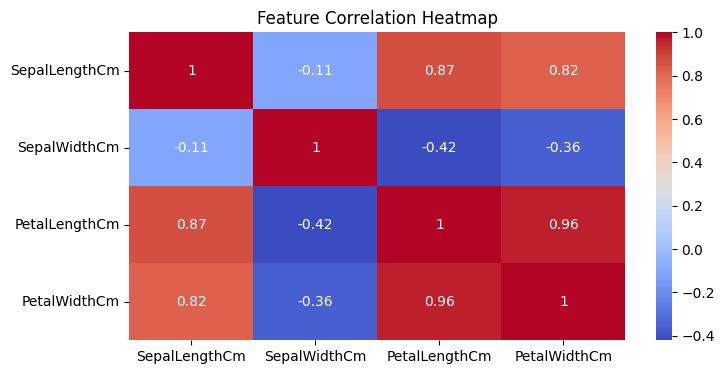

In [2]:
# Visualize the data distribution
sns.pairplot(df, hue='Species', markers=["o", "s", "D"])
plt.suptitle("Iris Flower Feature Distribution", y=1.02)
plt.show()

# Check for correlation between features
plt.figure(figsize=(8,4))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [3]:
# Split features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Encode the species names into numbers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a Random Forest Classifier (Professional choice for tabular data)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


Accuracy Score: 100.00%

Confusion Matrix:


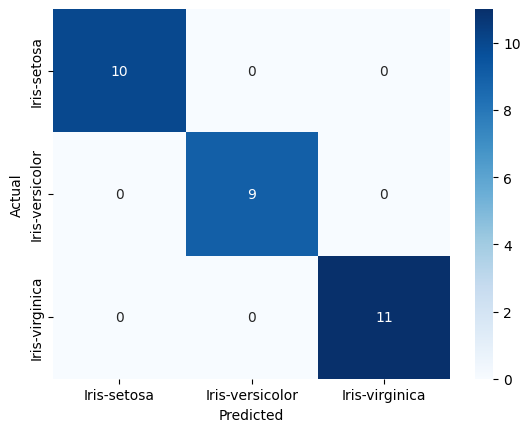


Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [4]:
# Make predictions
y_pred = model.predict(X_test)

# Print metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))